Video recording started: recordings/pose_estimation_20251102_165537.avi
Initializing AI Pose Estimation System...
Press 'q' to quit, 'a' to generate analytics report
Exercise Controls:
1:Bicep 2:Squat 3:Shoulder 4:Push-up 5:Lunge 6:Deadlift
7:Tricep 8:Lateral 9:Plank 0:Crunch a:LegRaise b:Pull-up
c:Row d:HipThrust r:Record
Bicep Curls left_arm: 1
Video recording OFF

Generating final analytics report...


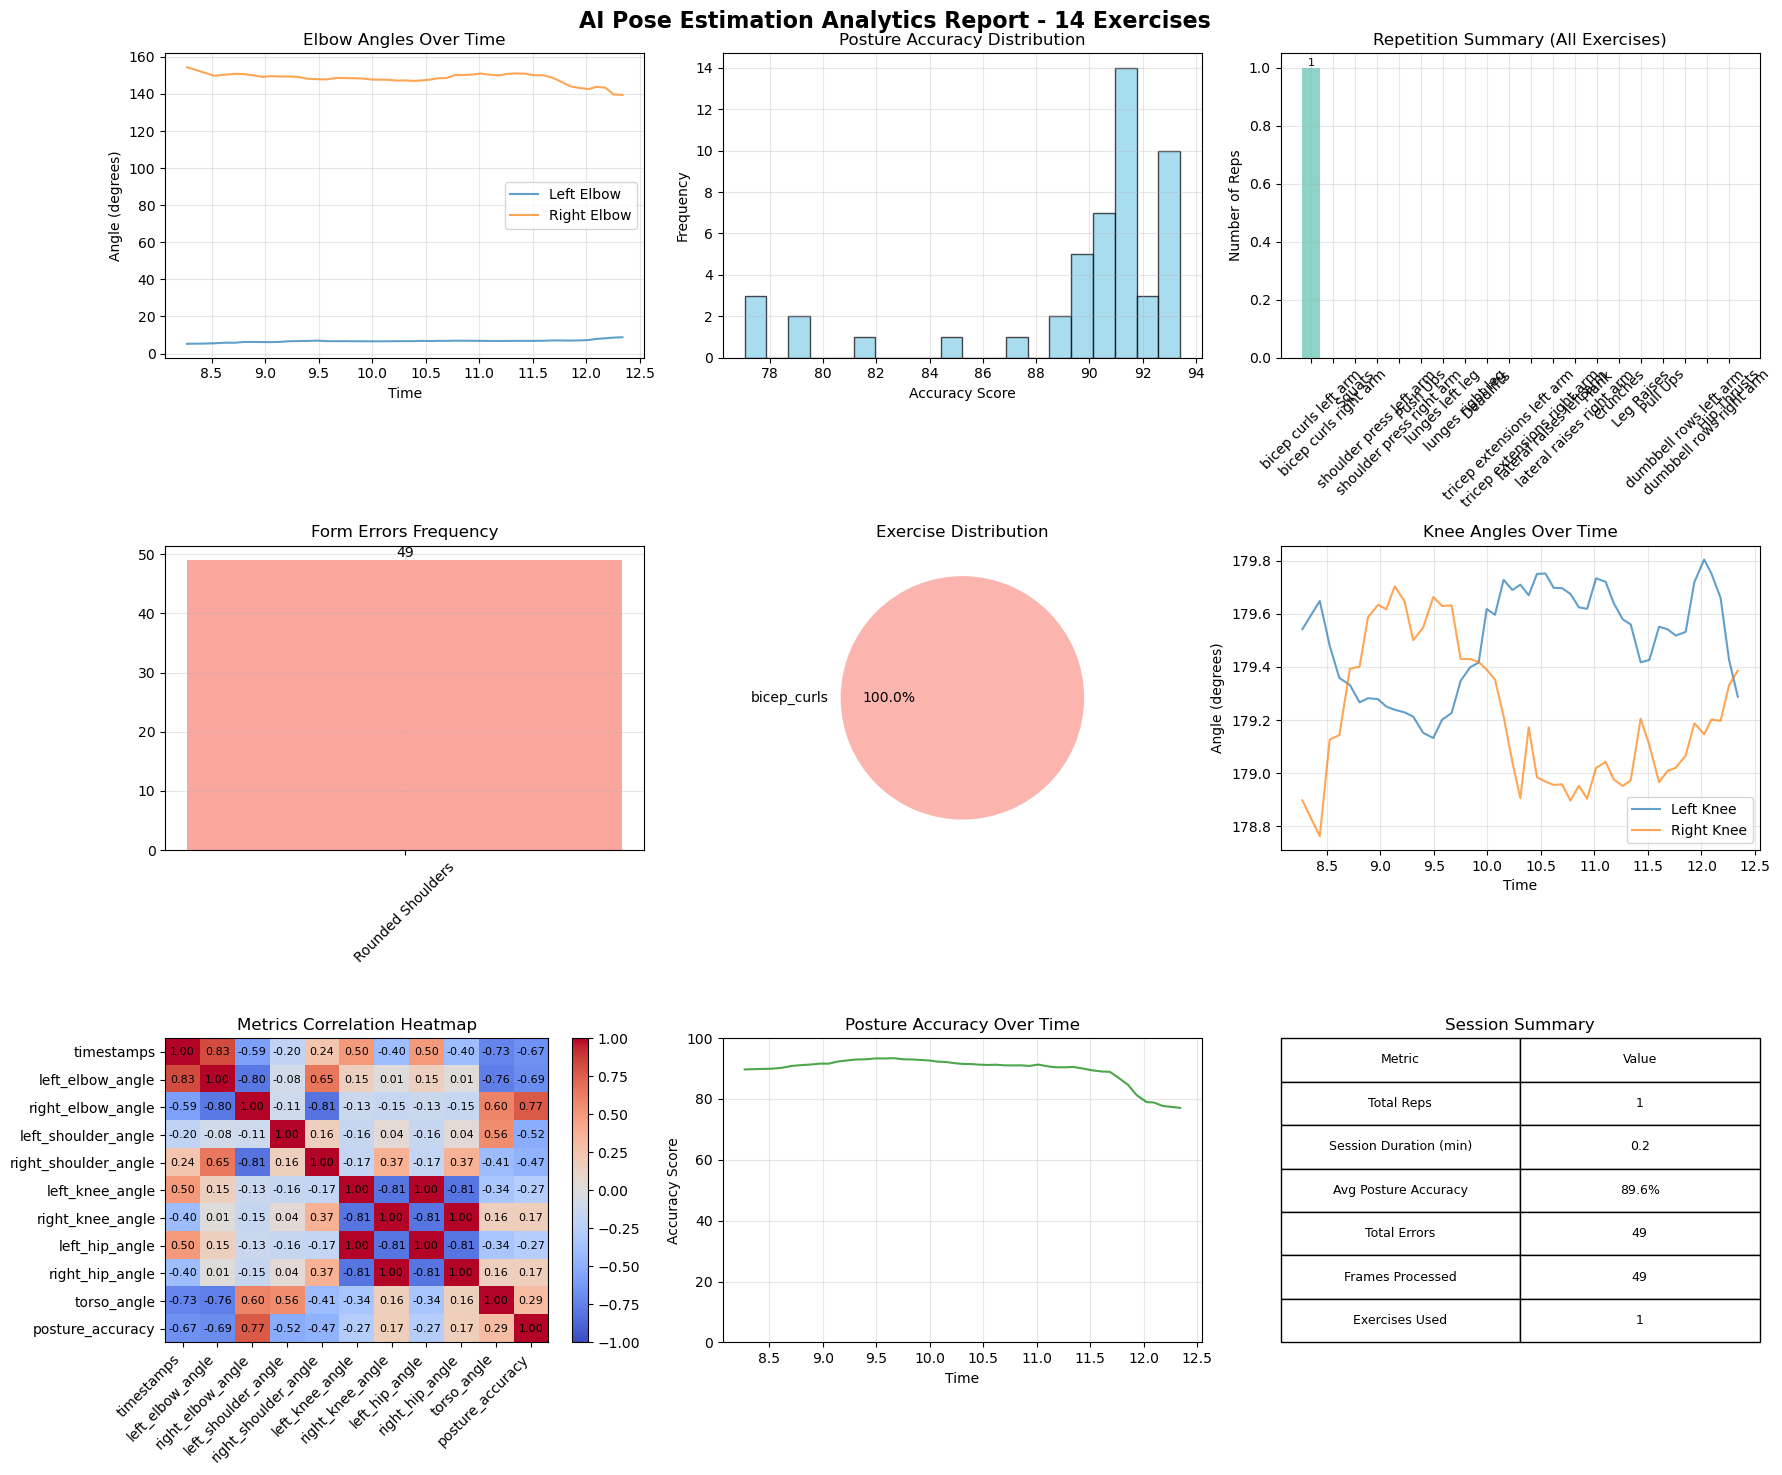


COMPREHENSIVE SESSION STATISTICS - 14 EXERCISES
Session Duration: 0.35 minutes
Total Frames Processed: 49
Average Posture Accuracy: 89.57%
Posture Consistency (Std Dev): 4.49%
Total Errors Detected: 49
Total Reps Completed: 1
Number of Exercises Used: 1

Reps by Exercise:
  Bicep Curls (left arm): 1

Most Common Error: Rounded Shoulders

Data saved to 'pose_estimation_data.csv'
Analytics report saved to 'pose_estimation_analytics.png'


In [ ]:


import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import time
import seaborn as sns
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import os

class PoseEstimationSystem:
    def __init__(self):
        self.mp_drawing = mp.solutions.drawing_utils
        self.mp_pose = mp.solutions.pose
        self.cap = None
        self.setup_mediapipe()
        self.setup_data_structures()
        self.setup_video_recording()

    def setup_video_recording(self):
        """Initialize video recording setup"""
        if not os.path.exists('recordings'):
            os.makedirs('recordings')

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.video_filename = f'recordings/pose_estimation_{timestamp}.avi'

        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        self.video_out = cv2.VideoWriter(
            self.video_filename,
            fourcc,
            20.0,
            (640, 480)
        )

        self.recording = True
        print(f"Video recording started: {self.video_filename}")

    def setup_mediapipe(self):
        """Initialize MediaPipe pose estimation"""
        self.pose = self.mp_pose.Pose(
            min_detection_confidence=0.7,
            min_tracking_confidence=0.7,
            model_complexity=1
        )

    def setup_data_structures(self):
        """Initialize data collection structures"""
        self.exercise_data = {
            'timestamps': [],
            'left_elbow_angle': [],
            'right_elbow_angle': [],
            'left_shoulder_angle': [],
            'right_shoulder_angle': [],
            'left_knee_angle': [],
            'right_knee_angle': [],
            'left_hip_angle': [],
            'right_hip_angle': [],
            'torso_angle': [],
            'posture_accuracy': [],
            'errors': [],
            'exercise_type': []
        }

        # Enhanced rep counting system for 14 exercises
        self.rep_counters = {
            # Original exercises
            'bicep_curls': {
                'left_arm': {'counter': 0, 'stage': 'down', 'last_rep_time': 0},
                'right_arm': {'counter': 0, 'stage': 'down', 'last_rep_time': 0}
            },
            'squats': {
                'counter': 0, 'stage': 'up', 'last_rep_time': 0
            },
            'shoulder_press': {
                'left_arm': {'counter': 0, 'stage': 'down', 'last_rep_time': 0},
                'right_arm': {'counter': 0, 'stage': 'down', 'last_rep_time': 0}
            },
            'push_ups': {
                'counter': 0, 'stage': 'up', 'last_rep_time': 0
            },
            # New exercises
            'lunges': {
                'left_leg': {'counter': 0, 'stage': 'up', 'last_rep_time': 0},
                'right_leg': {'counter': 0, 'stage': 'up', 'last_rep_time': 0}
            },
            'deadlifts': {
                'counter': 0, 'stage': 'up', 'last_rep_time': 0
            },
            'tricep_extensions': {
                'left_arm': {'counter': 0, 'stage': 'down', 'last_rep_time': 0},
                'right_arm': {'counter': 0, 'stage': 'down', 'last_rep_time': 0}
            },
            'lateral_raises': {
                'left_arm': {'counter': 0, 'stage': 'down', 'last_rep_time': 0},
                'right_arm': {'counter': 0, 'stage': 'down', 'last_rep_time': 0}
            },
            'plank': {
                'counter': 0, 'stage': 'hold', 'last_rep_time': 0, 'hold_time': 0
            },
            'crunches': {
                'counter': 0, 'stage': 'down', 'last_rep_time': 0
            },
            'leg_raises': {
                'counter': 0, 'stage': 'down', 'last_rep_time': 0
            },
            'pull_ups': {
                'counter': 0, 'stage': 'down', 'last_rep_time': 0
            },
            'dumbbell_rows': {
                'left_arm': {'counter': 0, 'stage': 'down', 'last_rep_time': 0},
                'right_arm': {'counter': 0, 'stage': 'down', 'last_rep_time': 0}
            },
            'hip_thrusts': {
                'counter': 0, 'stage': 'down', 'last_rep_time': 0
            }
        }

        self.current_exercise = 'bicep_curls'
        self.session_start_time = time.time()
        self.min_rep_interval = 1.0

    def calculate_angle(self, a, b, c):
        """Calculate angle between three points"""
        a = np.array(a)
        b = np.array(b)
        c = np.array(c)

        radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
        angle = np.abs(radians * 180.0 / np.pi)

        if angle > 180.0:
            angle = 360 - angle

        return angle

    def get_landmark_coordinates(self, landmarks, landmark_type):
        """Extract coordinates for specific landmarks"""
        coordinates = {}

        # Upper body landmarks
        if landmark_type == 'left_arm':
            coordinates['shoulder'] = [landmarks[self.mp_pose.PoseLandmark.LEFT_SHOULDER.value].x,
                                     landmarks[self.mp_pose.PoseLandmark.LEFT_SHOULDER.value].y]
            coordinates['elbow'] = [landmarks[self.mp_pose.PoseLandmark.LEFT_ELBOW.value].x,
                                  landmarks[self.mp_pose.PoseLandmark.LEFT_ELBOW.value].y]
            coordinates['wrist'] = [landmarks[self.mp_pose.PoseLandmark.LEFT_WRIST.value].x,
                                  landmarks[self.mp_pose.PoseLandmark.LEFT_WRIST.value].y]

        elif landmark_type == 'right_arm':
            coordinates['shoulder'] = [landmarks[self.mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x,
                                     landmarks[self.mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y]
            coordinates['elbow'] = [landmarks[self.mp_pose.PoseLandmark.RIGHT_ELBOW.value].x,
                                  landmarks[self.mp_pose.PoseLandmark.RIGHT_ELBOW.value].y]
            coordinates['wrist'] = [landmarks[self.mp_pose.PoseLandmark.RIGHT_WRIST.value].x,
                                  landmarks[self.mp_pose.PoseLandmark.RIGHT_WRIST.value].y]

        # Lower body landmarks
        elif landmark_type == 'left_leg':
            coordinates['hip'] = [landmarks[self.mp_pose.PoseLandmark.LEFT_HIP.value].x,
                                landmarks[self.mp_pose.PoseLandmark.LEFT_HIP.value].y]
            coordinates['knee'] = [landmarks[self.mp_pose.PoseLandmark.LEFT_KNEE.value].x,
                                 landmarks[self.mp_pose.PoseLandmark.LEFT_KNEE.value].y]
            coordinates['ankle'] = [landmarks[self.mp_pose.PoseLandmark.LEFT_ANKLE.value].x,
                                  landmarks[self.mp_pose.PoseLandmark.LEFT_ANKLE.value].y]

        elif landmark_type == 'right_leg':
            coordinates['hip'] = [landmarks[self.mp_pose.PoseLandmark.RIGHT_HIP.value].x,
                                landmarks[self.mp_pose.PoseLandmark.RIGHT_HIP.value].y]
            coordinates['knee'] = [landmarks[self.mp_pose.PoseLandmark.RIGHT_KNEE.value].x,
                                 landmarks[self.mp_pose.PoseLandmark.RIGHT_KNEE.value].y]
            coordinates['ankle'] = [landmarks[self.mp_pose.PoseLandmark.RIGHT_ANKLE.value].x,
                                  landmarks[self.mp_pose.PoseLandmark.RIGHT_ANKLE.value].y]

        # Torso landmarks
        elif landmark_type == 'torso':
            coordinates['shoulder'] = [landmarks[self.mp_pose.PoseLandmark.LEFT_SHOULDER.value].x,
                                     landmarks[self.mp_pose.PoseLandmark.LEFT_SHOULDER.value].y]
            coordinates['hip'] = [landmarks[self.mp_pose.PoseLandmark.LEFT_HIP.value].x,
                                landmarks[self.mp_pose.PoseLandmark.LEFT_HIP.value].y]
            coordinates['knee'] = [landmarks[self.mp_pose.PoseLandmark.LEFT_KNEE.value].x,
                                 landmarks[self.mp_pose.PoseLandmark.LEFT_KNEE.value].y]

        # Shoulder landmarks
        elif landmark_type == 'left_shoulder':
            coordinates['hip'] = [landmarks[self.mp_pose.PoseLandmark.LEFT_HIP.value].x,
                                landmarks[self.mp_pose.PoseLandmark.LEFT_HIP.value].y]
            coordinates['shoulder'] = [landmarks[self.mp_pose.PoseLandmark.LEFT_SHOULDER.value].x,
                                     landmarks[self.mp_pose.PoseLandmark.LEFT_SHOULDER.value].y]
            coordinates['elbow'] = [landmarks[self.mp_pose.PoseLandmark.LEFT_ELBOW.value].x,
                                  landmarks[self.mp_pose.PoseLandmark.LEFT_ELBOW.value].y]

        elif landmark_type == 'right_shoulder':
            coordinates['hip'] = [landmarks[self.mp_pose.PoseLandmark.RIGHT_HIP.value].x,
                                landmarks[self.mp_pose.PoseLandmark.RIGHT_HIP.value].y]
            coordinates['shoulder'] = [landmarks[self.mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x,
                                     landmarks[self.mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y]
            coordinates['elbow'] = [landmarks[self.mp_pose.PoseLandmark.RIGHT_ELBOW.value].x,
                                  landmarks[self.mp_pose.PoseLandmark.RIGHT_ELBOW.value].y]

        return coordinates

    def analyze_posture_accuracy(self, landmarks):
        """Analyze overall posture accuracy"""
        try:
            # Calculate symmetry between left and right sides
            left_shoulder = landmarks[self.mp_pose.PoseLandmark.LEFT_SHOULDER.value]
            right_shoulder = landmarks[self.mp_pose.PoseLandmark.RIGHT_SHOULDER.value]
            left_hip = landmarks[self.mp_pose.PoseLandmark.LEFT_HIP.value]
            right_hip = landmarks[self.mp_pose.PoseLandmark.RIGHT_HIP.value]

            # Shoulder level symmetry
            shoulder_diff = abs(left_shoulder.y - right_shoulder.y)
            hip_diff = abs(left_hip.y - right_hip.y)

            # Posture score (0-100, higher is better)
            posture_score = 100 - (shoulder_diff * 500 + hip_diff * 500)
            posture_score = max(0, min(100, posture_score))

            return posture_score
        except:
            return 0

    def detect_errors(self, landmarks):
        """Detect common exercise form errors"""
        errors = []

        try:
            # Check for rounded shoulders
            left_shoulder = landmarks[self.mp_pose.PoseLandmark.LEFT_SHOULDER.value]
            right_shoulder = landmarks[self.mp_pose.PoseLandmark.RIGHT_SHOULDER.value]
            left_ear = landmarks[self.mp_pose.PoseLandmark.LEFT_EAR.value]
            right_ear = landmarks[self.mp_pose.PoseLandmark.RIGHT_EAR.value]

            if left_shoulder.y > left_ear.y or right_shoulder.y > right_ear.y:
                errors.append("Rounded Shoulders")

            # Check for uneven hips
            left_hip = landmarks[self.mp_pose.PoseLandmark.LEFT_HIP.value]
            right_hip = landmarks[self.mp_pose.PoseLandmark.RIGHT_HIP.value]

            if abs(left_hip.y - right_hip.y) > 0.05:
                errors.append("Uneven Hips")

            # Exercise-specific error detection
            if self.current_exercise == 'deadlifts':
                # Check for rounded back in deadlifts
                shoulder = landmarks[self.mp_pose.PoseLandmark.LEFT_SHOULDER.value]
                hip = landmarks[self.mp_pose.PoseLandmark.LEFT_HIP.value]
                if shoulder.y < hip.y - 0.1:
                    errors.append("Rounded Back")

            elif self.current_exercise == 'squats':
                # Check for knees going past toes
                knee = landmarks[self.mp_pose.PoseLandmark.LEFT_KNEE.value]
                ankle = landmarks[self.mp_pose.PoseLandmark.LEFT_ANKLE.value]
                if knee.x < ankle.x - 0.05:
                    errors.append("Knees Past Toes")

        except:
            errors.append("Detection Error")

        return errors

    # Original exercise counting methods
    def count_bicep_curl_reps(self, left_angle, right_angle):
        """Count bicep curl repetitions"""
        current_time = time.time()
        reps_added = []

        # Left arm
        left_counter = self.rep_counters['bicep_curls']['left_arm']
        if left_angle > 160:
            left_counter['stage'] = "down"
        if left_angle < 30 and left_counter['stage'] == 'down':
            if current_time - left_counter['last_rep_time'] > self.min_rep_interval:
                left_counter['counter'] += 1
                left_counter['stage'] = "up"
                left_counter['last_rep_time'] = current_time
                reps_added.append('left_arm')

        # Right arm
        right_counter = self.rep_counters['bicep_curls']['right_arm']
        if right_angle > 160:
            right_counter['stage'] = "down"
        if right_angle < 30 and right_counter['stage'] == 'down':
            if current_time - right_counter['last_rep_time'] > self.min_rep_interval:
                right_counter['counter'] += 1
                right_counter['stage'] = "up"
                right_counter['last_rep_time'] = current_time
                reps_added.append('right_arm')

        return reps_added

    def count_squat_reps(self, left_knee_angle, right_knee_angle):
        """Count squat repetitions"""
        current_time = time.time()
        avg_knee_angle = (left_knee_angle + right_knee_angle) / 2
        squat_counter = self.rep_counters['squats']

        reps_added = []

        if avg_knee_angle > 160:
            squat_counter['stage'] = "up"
        if avg_knee_angle < 90 and squat_counter['stage'] == 'up':
            if current_time - squat_counter['last_rep_time'] > self.min_rep_interval:
                squat_counter['counter'] += 1
                squat_counter['stage'] = "down"
                squat_counter['last_rep_time'] = current_time
                reps_added.append('squat')

        return reps_added

    def count_shoulder_press_reps(self, left_shoulder_angle, right_shoulder_angle):
        """Count shoulder press repetitions"""
        current_time = time.time()
        reps_added = []

        # Left arm
        left_counter = self.rep_counters['shoulder_press']['left_arm']
        if left_shoulder_angle < 50:
            left_counter['stage'] = "down"
        if left_shoulder_angle > 160 and left_counter['stage'] == 'down':
            if current_time - left_counter['last_rep_time'] > self.min_rep_interval:
                left_counter['counter'] += 1
                left_counter['stage'] = "up"
                left_counter['last_rep_time'] = current_time
                reps_added.append('left_arm')

        # Right arm
        right_counter = self.rep_counters['shoulder_press']['right_arm']
        if right_shoulder_angle < 50:
            right_counter['stage'] = "down"
        if right_shoulder_angle > 160 and right_counter['stage'] == 'down':
            if current_time - right_counter['last_rep_time'] > self.min_rep_interval:
                right_counter['counter'] += 1
                right_counter['stage'] = "up"
                right_counter['last_rep_time'] = current_time
                reps_added.append('right_arm')

        return reps_added

    def count_push_up_reps(self, left_elbow_angle, right_elbow_angle):
        """Count push-up repetitions"""
        current_time = time.time()
        avg_elbow_angle = (left_elbow_angle + right_elbow_angle) / 2
        pushup_counter = self.rep_counters['push_ups']

        reps_added = []

        if avg_elbow_angle > 160:
            pushup_counter['stage'] = "up"
        if avg_elbow_angle < 90 and pushup_counter['stage'] == 'up':
            if current_time - pushup_counter['last_rep_time'] > self.min_rep_interval:
                pushup_counter['counter'] += 1
                pushup_counter['stage'] = "down"
                pushup_counter['last_rep_time'] = current_time
                reps_added.append('push_up')

        return reps_added

    # NEW EXERCISE COUNTING METHODS
    def count_lunge_reps(self, left_knee_angle, right_knee_angle):
        """Count lunge repetitions"""
        current_time = time.time()
        reps_added = []

        # Left leg
        left_counter = self.rep_counters['lunges']['left_leg']
        if left_knee_angle > 150:
            left_counter['stage'] = "up"
        if left_knee_angle < 90 and left_counter['stage'] == 'up':
            if current_time - left_counter['last_rep_time'] > self.min_rep_interval:
                left_counter['counter'] += 1
                left_counter['stage'] = "down"
                left_counter['last_rep_time'] = current_time
                reps_added.append('left_leg')

        # Right leg
        right_counter = self.rep_counters['lunges']['right_leg']
        if right_knee_angle > 150:
            right_counter['stage'] = "up"
        if right_knee_angle < 90 and right_counter['stage'] == 'up':
            if current_time - right_counter['last_rep_time'] > self.min_rep_interval:
                right_counter['counter'] += 1
                right_counter['stage'] = "down"
                right_counter['last_rep_time'] = current_time
                reps_added.append('right_leg')

        return reps_added

    def count_deadlift_reps(self, torso_angle):
        """Count deadlift repetitions"""
        current_time = time.time()
        deadlift_counter = self.rep_counters['deadlifts']

        reps_added = []

        if torso_angle < 30:  # Upright position
            deadlift_counter['stage'] = "up"
        if torso_angle > 60 and deadlift_counter['stage'] == 'up':  # Bent over
            if current_time - deadlift_counter['last_rep_time'] > self.min_rep_interval:
                deadlift_counter['counter'] += 1
                deadlift_counter['stage'] = "down"
                deadlift_counter['last_rep_time'] = current_time
                reps_added.append('deadlift')

        return reps_added

    def count_tricep_extension_reps(self, left_elbow_angle, right_elbow_angle):
        """Count tricep extension repetitions"""
        current_time = time.time()
        reps_added = []

        # Left arm
        left_counter = self.rep_counters['tricep_extensions']['left_arm']
        if left_elbow_angle > 160:
            left_counter['stage'] = "down"
        if left_elbow_angle < 45 and left_counter['stage'] == 'down':
            if current_time - left_counter['last_rep_time'] > self.min_rep_interval:
                left_counter['counter'] += 1
                left_counter['stage'] = "up"
                left_counter['last_rep_time'] = current_time
                reps_added.append('left_arm')

        # Right arm
        right_counter = self.rep_counters['tricep_extensions']['right_arm']
        if right_elbow_angle > 160:
            right_counter['stage'] = "down"
        if right_elbow_angle < 45 and right_counter['stage'] == 'down':
            if current_time - right_counter['last_rep_time'] > self.min_rep_interval:
                right_counter['counter'] += 1
                right_counter['stage'] = "up"
                right_counter['last_rep_time'] = current_time
                reps_added.append('right_arm')

        return reps_added

    def count_lateral_raise_reps(self, left_shoulder_angle, right_shoulder_angle):
        """Count lateral raise repetitions"""
        current_time = time.time()
        reps_added = []

        # Left arm
        left_counter = self.rep_counters['lateral_raises']['left_arm']
        if left_shoulder_angle < 20:
            left_counter['stage'] = "down"
        if left_shoulder_angle > 80 and left_counter['stage'] == 'down':
            if current_time - left_counter['last_rep_time'] > self.min_rep_interval:
                left_counter['counter'] += 1
                left_counter['stage'] = "up"
                left_counter['last_rep_time'] = current_time
                reps_added.append('left_arm')

        # Right arm
        right_counter = self.rep_counters['lateral_raises']['right_arm']
        if right_shoulder_angle < 20:
            right_counter['stage'] = "down"
        if right_shoulder_angle > 80 and right_counter['stage'] == 'down':
            if current_time - right_counter['last_rep_time'] > self.min_rep_interval:
                right_counter['counter'] += 1
                right_counter['stage'] = "up"
                right_counter['last_rep_time'] = current_time
                reps_added.append('right_arm')

        return reps_added

    def count_plank_time(self, torso_angle):
        """Count plank hold time"""
        plank_counter = self.rep_counters['plank']

        if 160 < torso_angle < 200:  # Straight body position
            plank_counter['hold_time'] += 1/30  # Assuming 30 FPS
            if plank_counter['hold_time'] >= 1.0:  # 1 second increments
                plank_counter['counter'] = int(plank_counter['hold_time'])
                return ['plank_second']
        return []

    def count_crunch_reps(self, torso_angle):
        """Count crunch repetitions"""
        current_time = time.time()
        crunch_counter = self.rep_counters['crunches']

        reps_added = []

        if torso_angle > 150:  # Lying down
            crunch_counter['stage'] = "down"
        if torso_angle < 120 and crunch_counter['stage'] == 'down':  # Crunched up
            if current_time - crunch_counter['last_rep_time'] > self.min_rep_interval:
                crunch_counter['counter'] += 1
                crunch_counter['stage'] = "up"
                crunch_counter['last_rep_time'] = current_time
                reps_added.append('crunch')

        return reps_added

    def count_leg_raise_reps(self, left_hip_angle, right_hip_angle):
        """Count leg raise repetitions"""
        current_time = time.time()
        avg_hip_angle = (left_hip_angle + right_hip_angle) / 2
        legraise_counter = self.rep_counters['leg_raises']

        reps_added = []

        if avg_hip_angle > 150:  # Legs down
            legraise_counter['stage'] = "down"
        if avg_hip_angle < 90 and legraise_counter['stage'] == 'down':  # Legs up
            if current_time - legraise_counter['last_rep_time'] > self.min_rep_interval:
                legraise_counter['counter'] += 1
                legraise_counter['stage'] = "up"
                legraise_counter['last_rep_time'] = current_time
                reps_added.append('leg_raise')

        return reps_added

    def count_pull_up_reps(self, left_elbow_angle, right_elbow_angle):
        """Count pull-up repetitions"""
        current_time = time.time()
        avg_elbow_angle = (left_elbow_angle + right_elbow_angle) / 2
        pullup_counter = self.rep_counters['pull_ups']

        reps_added = []

        if avg_elbow_angle > 160:  # Arms extended
            pullup_counter['stage'] = "down"
        if avg_elbow_angle < 60 and pullup_counter['stage'] == 'down':  # Chin over bar
            if current_time - pullup_counter['last_rep_time'] > self.min_rep_interval:
                pullup_counter['counter'] += 1
                pullup_counter['stage'] = "up"
                pullup_counter['last_rep_time'] = current_time
                reps_added.append('pull_up')

        return reps_added

    def count_dumbbell_row_reps(self, left_shoulder_angle, right_shoulder_angle):
        """Count dumbbell row repetitions"""
        current_time = time.time()
        reps_added = []

        # Left arm
        left_counter = self.rep_counters['dumbbell_rows']['left_arm']
        if left_shoulder_angle > 120:
            left_counter['stage'] = "down"
        if left_shoulder_angle < 60 and left_counter['stage'] == 'down':
            if current_time - left_counter['last_rep_time'] > self.min_rep_interval:
                left_counter['counter'] += 1
                left_counter['stage'] = "up"
                left_counter['last_rep_time'] = current_time
                reps_added.append('left_arm')

        # Right arm
        right_counter = self.rep_counters['dumbbell_rows']['right_arm']
        if right_shoulder_angle > 120:
            right_counter['stage'] = "down"
        if right_shoulder_angle < 60 and right_counter['stage'] == 'down':
            if current_time - right_counter['last_rep_time'] > self.min_rep_interval:
                right_counter['counter'] += 1
                right_counter['stage'] = "up"
                right_counter['last_rep_time'] = current_time
                reps_added.append('right_arm')

        return reps_added

    def count_hip_thrust_reps(self, left_hip_angle, right_hip_angle):
        """Count hip thrust repetitions"""
        current_time = time.time()
        avg_hip_angle = (left_hip_angle + right_hip_angle) / 2
        hipthrust_counter = self.rep_counters['hip_thrusts']

        reps_added = []

        if avg_hip_angle < 120:  # Hips down
            hipthrust_counter['stage'] = "down"
        if avg_hip_angle > 160 and hipthrust_counter['stage'] == 'down':  # Hips thrusted
            if current_time - hipthrust_counter['last_rep_time'] > self.min_rep_interval:
                hipthrust_counter['counter'] += 1
                hipthrust_counter['stage'] = "up"
                hipthrust_counter['last_rep_time'] = current_time
                reps_added.append('hip_thrust')

        return reps_added

    def update_exercise_type(self, key):
        """Change the current exercise type based on key press"""
        exercises = {
            '1': 'bicep_curls', '2': 'squats', '3': 'shoulder_press', '4': 'push_ups',
            '5': 'lunges', '6': 'deadlifts', '7': 'tricep_extensions', '8': 'lateral_raises',
            '9': 'plank', '0': 'crunches', 'a': 'leg_raises', 'b': 'pull_ups',
            'c': 'dumbbell_rows', 'd': 'hip_thrusts'
        }

        if key in exercises:
            self.current_exercise = exercises[key]
            print(f"Switched to: {self.current_exercise.replace('_', ' ').title()}")
            return True
        return False

    def get_total_reps(self):
        """Get total reps for current session"""
        total = 0
        for exercise, counters in self.rep_counters.items():
            if isinstance(counters, dict):
                if 'counter' in counters:  # Single counter
                    total += counters['counter']
                else:  # Multiple counters
                    for side, data in counters.items():
                        total += data['counter']
        return total

    def create_live_dashboard(self, image):
        """Create comprehensive dashboard overlay"""
        height, width = image.shape[:2]

        # Main dashboard background
        dashboard_bg = np.zeros((height, width, 3), dtype=np.uint8)

        # Exercise statistics panel
        stats_panel = np.zeros((250, 400, 3), dtype=np.uint8)
        stats_panel[:] = (50, 50, 50)

        # Add text information
        font = cv2.FONT_HERSHEY_SIMPLEX
        small_font = cv2.FONT_HERSHEY_PLAIN

        # Current exercise
        cv2.putText(stats_panel, f"Exercise: {self.current_exercise.replace('_', ' ').title()}",
                   (10, 20), font, 0.6, (0, 255, 255), 2)

        # Rep counters based on current exercise
        y_offset = 50

        if self.current_exercise in ['bicep_curls', 'shoulder_press', 'tricep_extensions',
                                   'lateral_raises', 'dumbbell_rows']:
            # Two-arm exercises
            left_count = self.rep_counters[self.current_exercise]['left_arm']['counter']
            right_count = self.rep_counters[self.current_exercise]['right_arm']['counter']
            cv2.putText(stats_panel, f"Left: {left_count}", (10, y_offset), font, 0.5, (255, 255, 255), 1)
            cv2.putText(stats_panel, f"Right: {right_count}", (10, y_offset + 25), font, 0.5, (255, 255, 255), 1)

        elif self.current_exercise in ['squats', 'push_ups', 'deadlifts', 'plank',
                                     'crunches', 'leg_raises', 'pull_ups', 'hip_thrusts']:
            # Single counter exercises
            count = self.rep_counters[self.current_exercise]['counter']
            cv2.putText(stats_panel, f"Reps: {count}", (10, y_offset), font, 0.5, (255, 255, 255), 1)

        elif self.current_exercise == 'lunges':
            # Leg-specific exercises
            left_count = self.rep_counters[self.current_exercise]['left_leg']['counter']
            right_count = self.rep_counters[self.current_exercise]['right_leg']['counter']
            cv2.putText(stats_panel, f"Left Leg: {left_count}", (10, y_offset), font, 0.5, (255, 255, 255), 1)
            cv2.putText(stats_panel, f"Right Leg: {right_count}", (10, y_offset + 25), font, 0.5, (255, 255, 255), 1)

        # Total reps
        cv2.putText(stats_panel, f"Total Reps: {self.get_total_reps()}",
                   (10, y_offset + 60), font, 0.6, (0, 255, 0), 2)

        # Session duration
        session_time = time.time() - self.session_start_time
        cv2.putText(stats_panel, f"Time: {int(session_time//60):02d}:{int(session_time%60):02d}",
                   (10, y_offset + 90), font, 0.5, (255, 255, 255), 1)

        # Exercise instructions
        instructions = [
            "1:Bicep 2:Squat 3:Shoulder 4:Push-up",
            "5:Lunge 6:Deadlift 7:Tricep 8:Lateral",
            "9:Plank 0:Crunch a:LegRaise b:Pull-up",
            "c:Row d:HipThrust r:Record a:Analytics"
        ]

        for i, instruction in enumerate(instructions):
            cv2.putText(stats_panel, instruction, (10, y_offset + 120 + i*20),
                       small_font, 0.5, (255, 255, 0), 1)

        # Recording status
        recording_status = "REC ON" if self.recording else "REC OFF"
        color = (0, 255, 0) if self.recording else (0, 0, 255)
        cv2.putText(stats_panel, f"R:{recording_status}",
                   (350, y_offset + 120), small_font, 0.6, color, 1)

        # Place stats panel on dashboard
        dashboard_bg[10:260, 10:410] = stats_panel

        # Combine with original image
        result = cv2.addWeighted(image, 0.7, dashboard_bg, 0.3, 0)
        return result

    def generate_analytics_report(self):
        """Generate comprehensive analytics report"""
        if len(self.exercise_data['timestamps']) == 0:
            print("No data collected for analysis")
            return

        # Create figure for analytics
        fig, axes = plt.subplots(3, 3, figsize=(18, 15))
        fig.suptitle('AI Pose Estimation Analytics Report - 14 Exercises', fontsize=16, fontweight='bold')

        # Convert to DataFrame for easier analysis
        df = pd.DataFrame(self.exercise_data)

        # 1. Angle trends over time
        if len(df) > 1:
            axes[0, 0].plot(df['timestamps'], df['left_elbow_angle'], label='Left Elbow', alpha=0.7)
            axes[0, 0].plot(df['timestamps'], df['right_elbow_angle'], label='Right Elbow', alpha=0.7)
            axes[0, 0].set_title('Elbow Angles Over Time')
            axes[0, 0].set_xlabel('Time')
            axes[0, 0].set_ylabel('Angle (degrees)')
            axes[0, 0].legend()
            axes[0, 0].grid(True, alpha=0.3)

        # 2. Posture accuracy distribution
        axes[0, 1].hist(df['posture_accuracy'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
        axes[0, 1].set_title('Posture Accuracy Distribution')
        axes[0, 1].set_xlabel('Accuracy Score')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].grid(True, alpha=0.3)

        # 3. Repetition summary
        exercise_reps = []
        rep_counts = []

        for exercise, counters in self.rep_counters.items():
            if isinstance(counters, dict):
                if 'counter' in counters:
                    exercise_reps.append(exercise.replace('_', ' ').title())
                    rep_counts.append(counters['counter'])
                else:
                    for side, data in counters.items():
                        exercise_reps.append(f"{exercise.replace('_', ' ')} {side.replace('_', ' ')}")
                        rep_counts.append(data['counter'])

        if exercise_reps:
            bars = axes[0, 2].bar(exercise_reps, rep_counts, color=plt.cm.Set3(np.linspace(0, 1, len(exercise_reps))))
            axes[0, 2].set_title('Repetition Summary (All Exercises)')
            axes[0, 2].set_ylabel('Number of Reps')
            axes[0, 2].tick_params(axis='x', rotation=45)
            axes[0, 2].grid(True, alpha=0.3)

            # Add value labels on bars
            for bar in bars:
                height = bar.get_height()
                if height > 0:
                    axes[0, 2].text(bar.get_x() + bar.get_width()/2., height,
                                   f'{int(height)}', ha='center', va='bottom', fontsize=8)

        # 4. Error frequency
        all_errors = [error for sublist in df['errors'] for error in sublist]
        if all_errors:
            error_counts = pd.Series(all_errors).value_counts()
            bars = axes[1, 0].bar(error_counts.index, error_counts.values, color='salmon', alpha=0.7)
            axes[1, 0].set_title('Form Errors Frequency')
            axes[1, 0].tick_params(axis='x', rotation=45)
            axes[1, 0].grid(True, alpha=0.3)

            # Add value labels on bars
            for bar in bars:
                height = bar.get_height()
                axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                               f'{int(height)}', ha='center', va='bottom')

        # 5. Exercise distribution
        if 'exercise_type' in df and len(df['exercise_type']) > 0:
            exercise_counts = df['exercise_type'].value_counts()
            axes[1, 1].pie(exercise_counts.values, labels=exercise_counts.index, autopct='%1.1f%%',
                          colors=plt.cm.Pastel1(np.linspace(0, 1, len(exercise_counts))))
            axes[1, 1].set_title('Exercise Distribution')

        # 6. Knee angles over time
        if len(df) > 1:
            axes[1, 2].plot(df['timestamps'], df['left_knee_angle'], label='Left Knee', alpha=0.7)
            axes[1, 2].plot(df['timestamps'], df['right_knee_angle'], label='Right Knee', alpha=0.7)
            axes[1, 2].set_title('Knee Angles Over Time')
            axes[1, 2].set_xlabel('Time')
            axes[1, 2].set_ylabel('Angle (degrees)')
            axes[1, 2].legend()
            axes[1, 2].grid(True, alpha=0.3)

        # 7. Correlation heatmap
        numeric_df = df.select_dtypes(include=[np.number])
        if len(numeric_df.columns) > 1:
            correlation_matrix = numeric_df.corr()
            im = axes[2, 0].imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
            axes[2, 0].set_title('Metrics Correlation Heatmap')
            axes[2, 0].set_xticks(range(len(correlation_matrix.columns)))
            axes[2, 0].set_yticks(range(len(correlation_matrix.columns)))
            axes[2, 0].set_xticklabels(correlation_matrix.columns, rotation=45, ha='right')
            axes[2, 0].set_yticklabels(correlation_matrix.columns)
            plt.colorbar(im, ax=axes[2, 0])

            # Add correlation values as text
            for i in range(len(correlation_matrix.columns)):
                for j in range(len(correlation_matrix.columns)):
                    text = axes[2, 0].text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                                          ha="center", va="center", color="black", fontsize=8)

        # 8. Posture accuracy over time
        if len(df) > 1:
            axes[2, 1].plot(df['timestamps'], df['posture_accuracy'], color='green', alpha=0.7)
            axes[2, 1].set_title('Posture Accuracy Over Time')
            axes[2, 1].set_xlabel('Time')
            axes[2, 1].set_ylabel('Accuracy Score')
            axes[2, 1].grid(True, alpha=0.3)
            axes[2, 1].set_ylim(0, 100)

        # 9. Summary statistics table
        summary_data = {
            'Metric': ['Total Reps', 'Session Duration (min)', 'Avg Posture Accuracy',
                      'Total Errors', 'Frames Processed', 'Exercises Used'],
            'Value': [self.get_total_reps(),
                     f"{(time.time() - self.session_start_time)/60:.1f}",
                     f"{df['posture_accuracy'].mean():.1f}%",
                     len(all_errors),
                     len(df),
                     df['exercise_type'].nunique() if 'exercise_type' in df else 0]
        }

        summary_df = pd.DataFrame(summary_data)
        axes[2, 2].axis('off')
        table = axes[2, 2].table(cellText=summary_df.values,
                                colLabels=summary_df.columns,
                                cellLoc='center',
                                loc='center',
                                bbox=[0, 0, 1, 1])
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1, 1.5)
        axes[2, 2].set_title('Session Summary')

        plt.tight_layout()
        plt.savefig('pose_estimation_analytics.png', dpi=300, bbox_inches='tight')
        plt.show()

        # Print detailed statistics
        print("\n" + "="*60)
        print("COMPREHENSIVE SESSION STATISTICS - 14 EXERCISES")
        print("="*60)
        print(f"Session Duration: {(time.time() - self.session_start_time)/60:.2f} minutes")
        print(f"Total Frames Processed: {len(df)}")
        print(f"Average Posture Accuracy: {df['posture_accuracy'].mean():.2f}%")
        print(f"Posture Consistency (Std Dev): {df['posture_accuracy'].std():.2f}%")
        print(f"Total Errors Detected: {len(all_errors)}")
        print(f"Total Reps Completed: {self.get_total_reps()}")
        print(f"Number of Exercises Used: {df['exercise_type'].nunique() if 'exercise_type' in df else 0}")

        # Print reps by exercise
        print("\nReps by Exercise:")
        for exercise, counters in self.rep_counters.items():
            if isinstance(counters, dict):
                if 'counter' in counters:
                    if counters['counter'] > 0:
                        print(f"  {exercise.replace('_', ' ').title()}: {counters['counter']}")
                else:
                    for side, data in counters.items():
                        if data['counter'] > 0:
                            print(f"  {exercise.replace('_', ' ').title()} ({side.replace('_', ' ')}): {data['counter']}")

        if all_errors:
            print(f"\nMost Common Error: {pd.Series(all_errors).mode().iloc[0]}")

        # Save data to CSV
        df.to_csv('pose_estimation_data.csv', index=False)
        print(f"\nData saved to 'pose_estimation_data.csv'")
        print(f"Analytics report saved to 'pose_estimation_analytics.png'")

    def run_pose_estimation(self):
        """Main method to run pose estimation system"""
        print("Initializing AI Pose Estimation System...")
        print("Press 'q' to quit, 'a' to generate analytics report")
        print("Exercise Controls:")
        print("1:Bicep 2:Squat 3:Shoulder 4:Push-up 5:Lunge 6:Deadlift")
        print("7:Tricep 8:Lateral 9:Plank 0:Crunch a:LegRaise b:Pull-up")
        print("c:Row d:HipThrust r:Record")

        self.cap = cv2.VideoCapture(0)
        if not self.cap.isOpened():
            print("Error: Could not open webcam")
            return

        try:
            while self.cap.isOpened():
                ret, frame = self.cap.read()
                if not ret:
                    print("Error: Failed to capture frame")
                    break

                # Process frame
                image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                image.flags.writeable = False
                results = self.pose.process(image)
                image.flags.writeable = True
                image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

                current_time = time.time() - self.session_start_time

                try:
                    if results.pose_landmarks:
                        landmarks = results.pose_landmarks.landmark

                        # Analyze different body parts
                        body_parts = ['left_arm', 'right_arm', 'left_leg', 'right_leg',
                                    'left_shoulder', 'right_shoulder', 'torso']
                        angles = {}

                        for part in body_parts:
                            coords = self.get_landmark_coordinates(landmarks, part)

                            if 'shoulder' in coords and 'elbow' in coords and 'wrist' in coords:
                                angle = self.calculate_angle(coords['shoulder'], coords['elbow'], coords['wrist'])
                                angles[f'{part}_angle'] = angle

                            elif 'hip' in coords and 'knee' in coords and 'ankle' in coords:
                                angle = self.calculate_angle(coords['hip'], coords['knee'], coords['ankle'])
                                angles[f'{part}_angle'] = angle
                                # Also store as hip angle for specific exercises
                                if 'left' in part:
                                    angles['left_hip_angle'] = angle
                                else:
                                    angles['right_hip_angle'] = angle

                            elif 'hip' in coords and 'shoulder' in coords and 'elbow' in coords:
                                angle = self.calculate_angle(coords['hip'], coords['shoulder'], coords['elbow'])
                                angles[f'{part}_angle'] = angle

                            elif 'shoulder' in coords and 'hip' in coords and 'knee' in coords:
                                angle = self.calculate_angle(coords['shoulder'], coords['hip'], coords['knee'])
                                angles['torso_angle'] = angle

                        # Count reps based on current exercise
                        reps_added = []
                        if self.current_exercise == 'bicep_curls':
                            reps_added = self.count_bicep_curl_reps(
                                angles.get('left_arm_angle', 0),
                                angles.get('right_arm_angle', 0)
                            )
                        elif self.current_exercise == 'squats':
                            reps_added = self.count_squat_reps(
                                angles.get('left_leg_angle', 0),
                                angles.get('right_leg_angle', 0)
                            )
                        elif self.current_exercise == 'shoulder_press':
                            reps_added = self.count_shoulder_press_reps(
                                angles.get('left_shoulder_angle', 0),
                                angles.get('right_shoulder_angle', 0)
                            )
                        elif self.current_exercise == 'push_ups':
                            reps_added = self.count_push_up_reps(
                                angles.get('left_arm_angle', 0),
                                angles.get('right_arm_angle', 0)
                            )
                        # New exercises
                        elif self.current_exercise == 'lunges':
                            reps_added = self.count_lunge_reps(
                                angles.get('left_leg_angle', 0),
                                angles.get('right_leg_angle', 0)
                            )
                        elif self.current_exercise == 'deadlifts':
                            reps_added = self.count_deadlift_reps(
                                angles.get('torso_angle', 0)
                            )
                        elif self.current_exercise == 'tricep_extensions':
                            reps_added = self.count_tricep_extension_reps(
                                angles.get('left_arm_angle', 0),
                                angles.get('right_arm_angle', 0)
                            )
                        elif self.current_exercise == 'lateral_raises':
                            reps_added = self.count_lateral_raise_reps(
                                angles.get('left_shoulder_angle', 0),
                                angles.get('right_shoulder_angle', 0)
                            )
                        elif self.current_exercise == 'plank':
                            reps_added = self.count_plank_time(
                                angles.get('torso_angle', 0)
                            )
                        elif self.current_exercise == 'crunches':
                            reps_added = self.count_crunch_reps(
                                angles.get('torso_angle', 0)
                            )
                        elif self.current_exercise == 'leg_raises':
                            reps_added = self.count_leg_raise_reps(
                                angles.get('left_hip_angle', 0),
                                angles.get('right_hip_angle', 0)
                            )
                        elif self.current_exercise == 'pull_ups':
                            reps_added = self.count_pull_up_reps(
                                angles.get('left_arm_angle', 0),
                                angles.get('right_arm_angle', 0)
                            )
                        elif self.current_exercise == 'dumbbell_rows':
                            reps_added = self.count_dumbbell_row_reps(
                                angles.get('left_shoulder_angle', 0),
                                angles.get('right_shoulder_angle', 0)
                            )
                        elif self.current_exercise == 'hip_thrusts':
                            reps_added = self.count_hip_thrust_reps(
                                angles.get('left_hip_angle', 0),
                                angles.get('right_hip_angle', 0)
                            )

                        # Print rep notifications
                        for rep in reps_added:
                            print(f"{self.current_exercise.replace('_', ' ').title()} {rep}: {self.get_current_count(rep)}")

                        # Analyze posture and errors
                        posture_accuracy = self.analyze_posture_accuracy(landmarks)
                        errors = self.detect_errors(landmarks)

                        # Store data
                        self.exercise_data['timestamps'].append(current_time)
                        self.exercise_data['left_elbow_angle'].append(angles.get('left_arm_angle', 0))
                        self.exercise_data['right_elbow_angle'].append(angles.get('right_arm_angle', 0))
                        self.exercise_data['left_shoulder_angle'].append(angles.get('left_shoulder_angle', 0))
                        self.exercise_data['right_shoulder_angle'].append(angles.get('right_shoulder_angle', 0))
                        self.exercise_data['left_knee_angle'].append(angles.get('left_leg_angle', 0))
                        self.exercise_data['right_knee_angle'].append(angles.get('right_leg_angle', 0))
                        self.exercise_data['left_hip_angle'].append(angles.get('left_hip_angle', 0))
                        self.exercise_data['right_hip_angle'].append(angles.get('right_hip_angle', 0))
                        self.exercise_data['torso_angle'].append(angles.get('torso_angle', 0))
                        self.exercise_data['posture_accuracy'].append(posture_accuracy)
                        self.exercise_data['errors'].append(errors)
                        self.exercise_data['exercise_type'].append(self.current_exercise)

                        # Display angles on image
                        for part in ['left_arm', 'right_arm']:
                            coords = self.get_landmark_coordinates(landmarks, part)
                            if 'elbow' in coords:
                                angle = angles.get(f'{part}_angle', 0)
                                elbow_pos = tuple(np.multiply(coords['elbow'], [image.shape[1], image.shape[0]]).astype(int))
                                cv2.putText(image, f'{angle:.1f}°', elbow_pos,
                                          cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

                except Exception as e:
                    print(f"Error in pose analysis: {e}")

                # Render pose landmarks
                self.mp_drawing.draw_landmarks(
                    image, results.pose_landmarks, self.mp_pose.POSE_CONNECTIONS,
                    self.mp_drawing.DrawingSpec(color=(245, 117, 66), thickness=2, circle_radius=2),
                    self.mp_drawing.DrawingSpec(color=(245, 66, 230), thickness=2, circle_radius=2)
                )

                # Create and display dashboard
                dashboard_image = self.create_live_dashboard(image)

                # Save frame if recording
                if self.recording:
                    self.video_out.write(dashboard_image)

                cv2.imshow('AI Pose Estimation System - 14 Exercises', dashboard_image)

                # Handle key presses
                key = cv2.waitKey(10) & 0xFF
                if key == ord('q'):
                    break
                elif key == ord('a'):
                    self.generate_analytics_report()
                elif key == ord('r'):
                    self.recording = not self.recording
                    status = "ON" if self.recording else "OFF"
                    print(f"Video recording {status}")
                else:
                    self.update_exercise_type(chr(key))

        finally:
            # Cleanup
            self.cap.release()
            if hasattr(self, 'video_out') and self.recording:
                self.video_out.release()
                print(f"Video saved as: {self.video_filename}")
            cv2.destroyAllWindows()
            self.pose.close()

            # Generate final report
            print("\nGenerating final analytics report...")
            self.generate_analytics_report()

    def get_current_count(self, rep_type):
        """Get current count for rep type"""
        if 'left_arm' in rep_type:
            return self.rep_counters[self.current_exercise]['left_arm']['counter']
        elif 'right_arm' in rep_type:
            return self.rep_counters[self.current_exercise]['right_arm']['counter']
        elif 'left_leg' in rep_type:
            return self.rep_counters[self.current_exercise]['left_leg']['counter']
        elif 'right_leg' in rep_type:
            return self.rep_counters[self.current_exercise]['right_leg']['counter']
        else:
            return self.rep_counters[self.current_exercise]['counter']

# Main execution
if __name__ == "__main__":
    pose_system = PoseEstimationSystem()
    pose_system.run_pose_estimation()